# L5d Lab: Assigning Faculty to Courses as a Minimum-Cost Flow

Every semester, the department must decide who teaches what. Faculty owe a set number of courses, some courses need a team, and a survey records how prepared each person is to teach each course. We will find the schedule that follows every rule and best matches the survey, then change the data and watch how the schedule responds.



> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Translate rules into bounds and costs:__ Express teaching loads, staffing limits, and survey scores as lower bounds, capacities, and costs on a flow network. Explain how a default score keeps an unspecified pairing available at a high cost.
> * __Build and solve the linear program:__ Assemble the incidence matrix, required net flows, costs, and bounds, and solve for the lowest-cost schedule. Read the assignments from the edge flows and check them against the department's rules.
> * __Predict the effect of changes:__ Predict how the schedule responds when a survey score, the number of courses someone must teach, or another rule changes, and check the prediction against the flow diagram. Explain why a change in cost reranks the same schedules while a change in a bound can remove them.

In this lab, we build the network from the department's tables, solve the linear program, and then change the data live, predicting each new schedule before we solve. The code is complete, and each task ends with discussion of what the model tells us.

Let's get started!

___

## Setup, Data, and Prerequisites

First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the course library, this lab's department, flow-model, and plotting helpers, and the packages used here.

Let's set up our code environment:

In [1]:
# Load packages, data paths, and lab functions -
include(joinpath(@__DIR__, "Include.jl")) # @__DIR__ locates this notebook's setup file

# Choose the plot appearance -
# After changing the theme, rerun this cell and the plotting cells.
# A single figure can override this choice with the keyword theme = :dark.
theme(:default)   # light background
# theme(:dark)   # dark background

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5800 course library documentation](https://varnerlab.org/CHEME-5800-CourseRepository-Fall-2026/dev/library/) for the functions and types used here.

The CSV files in the [data folder](data/README.md) hold the number of courses each faculty member must teach, course staffing limits, and survey scores. The course codes are real; the faculty, A through J, and their data are synthetic. The lab's functions are complete and live in [src/Compute.jl](src/Compute.jl).

__Optional exercise:__ After class, rebuild [the `build_teaching_network(...)` function](docs/build_teaching_network.md) from its docstring, restart the kernel to load your changes, and rerun the notebook; the reference is in [src/Compute-solution.jl](src/Compute-solution.jl).

___

## Task 1: Build the teaching-assignment network

In this task, we read the department's tables and translate its teaching rules into a flow network. We first identify the assignments the department allows, then use edge bounds to express how many courses each faculty member must teach and how many instructors each course needs.

### The department's tables

[The `read_department(...)` function](docs/read_department.md) reads the CSV files, replaces blank preferences with the default score of 3, and checks that the faculty names, course codes, and survey entries agree. It returns the `department::NamedTuple` data structure, which holds the faculty, course, and survey tables. For example, `department.courses` contains one row per course; its `min_faculty` and `max_faculty` columns give the smallest and largest permitted teaching teams.

Let's read the data and display the course staffing limits. Equal limits prescribe an exact team size, while a minimum of zero allows a course to remain unstaffed:

In [2]:
# Read and validate the department data -
department = read_department(CHEME5800_L5D_DATA); # loads, staffing bounds, and scores

# Display the staffing rules -
# Select all course rows and only the four columns needed to interpret the bounds.
pretty_table(department.courses[:, [:course, :title, :min_faculty, :max_faculty]];
    backend = :text, # plain-text output remains readable in either notebook theme
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = ["Course", "Title", "Minimum", "Maximum"],
    alignment = [:l, :l, :r, :r], # left-align names and right-align staffing counts
    fit_table_in_display_horizontally = false, # print every column
)

 ------------ ---------------------------------------------------------------------- --------- ---------
  Course       Title                                                                  Minimum   Maximum 
 ------------ ---------------------------------------------------------------------- --------- ---------
  ENGRI-1120   Feast! Chemical and Biomolecular Processes and Products through Food         1         1
  ENGRD-2190   Chemical Process Design and Analysis                                         1         1
  CHEME-2880   Biomolecular Engineering: Fundamentals and Applications                      1         1
  CHEME-3130   Chemical Engineering Thermodynamics                                          1         1
  CHEME-3240   Heat and Mass Transfer                                                       1         1
  CHEME-4320   Chemical Engineering Capstone Design I                                       3         3
  CHEME-5310   Principles of Electrochemical Engineering     

__Required core versus elective courses__: The staffing bounds distinguish required courses from optional (elective) courses. Equal positive bounds prescribe an exact teaching-team size. A minimum of zero and a maximum of one make a course an optional elective: zero assignments means it is not taught that semester, while one assignment means it runs with one instructor.

Each member of a teaching team counts that course as one of the courses they must teach.

Next, we combine the number of courses each faculty member must teach with the preference table. Each row describes one faculty member: `Load` is the exact number of courses they must teach, and each course column gives the score (cost) used by the model.

The loaded table includes the default cost wherever the input file left a preference blank:

In [3]:
# Combine the faculty loads with the complete preference table -
# Blank input entries have already received the default score in read_department(...).
survey_table = hcat(department.faculty, department.preferences[:, Not(:name)]);

# Display the scores used by the model -
pretty_table(survey_table;
    backend = :text,
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = vcat(["Faculty", "Load"], replace.(department.courses.course, r"^[A-Z]+-" => "")),
    alignment = :c,
    fit_table_in_display_horizontally = false, # keep all course scores visible
)

 --------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
  Faculty   Load   1120   2190   2880   3130   3240   4320   5310   6110   6230   6310   6440   6800 
 --------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
     A       2      3      0      3      1      3      0      3      3      3      3      3      2
     B       1      1      3      0      3      2      3      3      3      3      0      3      3
     C       1      3      3      3      0      3      2      2      1      3      3      3      3
     D       2      3      2      3      3      0      1      3      1      0      3      3      3
     E       1      2      3      3      1      3      1      0      3      3      3      3      3
     F       2      3      1      3      3      3      3      3      1      3      3      2      0
     G       1      0      3      3      3      3      3      3      3      3      2      1      3
 

__Preference survey__: Each year, the department conducts a preference survey to gather information about faculty members' availability and preferences for teaching specific courses. 

The survey records a `0` for prepared to teach, a `1` for comfortable teaching, a `2` for interested in developing expertise, and a `3` for needing significant support or lead time. We use these numbers as additive costs: a smaller total is preferred by this model. A blank input receives the default score of `3`. 

For example, faculty member A has a `Load` of 2, so every schedule must give A exactly two courses. The solver chooses the assignments to minimize the total preference cost, while satisfying all faculty loads and course staffing requirements.

### From rules to a network
The network must satisfy each faculty member's teaching load and each course's staffing limits. We enforce teaching loads on the edges entering faculty nodes and staffing limits on the edges leaving course nodes. Flow conservation connects these requirements: every assignment counts toward both a faculty member's load and a course's staffing.

For each course, the total assigned flow passes through its completion node to the sink. The following table specifies the edge bounds and costs that express the department's rules and preferences:

| Rule | Edge $j$ | Lower bound $\ell_j$ | Capacity $c_j$ | Cost $w_j$ per assignment |
|---|---|---|---|---|
| Exact teaching load | source → faculty node $i$ | $L_i$ | $L_i$ | 0 |
| Survey score | faculty node $i$ → course node $k$ | 0 | 1 | survey score |
| Blank input preference | faculty node $i$ → course node $k$ | 0 | 1 | default score 3 |
| Staffing bounds | course node $k$ → its completion node | $m_k$ | $M_k$ | 0 |
| Course completion | completion node → sink | 0 | $M_k$ | 0 |

Here $L_i$ is the number of courses the faculty member at node $i$ must teach, and $m_k$ and $M_k$ are the staffing limits of the course at node $k$. As in the L5c lecture, $c_j$ is the capacity and $w_j$ the cost of edge $j$; the lower bound $\ell_j$ is new. Equal bounds on a faculty load edge require that load to be met exactly. A faculty-to-course capacity of one prevents the same person from filling two positions on one teaching team. Only faculty-to-course edges have nonzero costs, so an assignment contributes its survey score once to the objective.

[The `build_teaching_network(...)` function](docs/build_teaching_network.md) builds `network` from these rules. The nodes follow the layers in the diagram: source, faculty, courses, course completion, and sink. Faculty and courses appear in file order. The returned `network.edges` records each edge's endpoints, lower and upper bounds, and cost. Its name-to-node dictionaries let us locate a faculty member or course without remembering these node numbers.

The next cell constructs this network and counts its edges by role. It also reports `required_flow`, the total teaching load that must reach the sink:

In [4]:
# Translate the department rules into edges with bounds and costs -
network = build_teaching_network(department); # one unit of flow represents one assignment

# Count the nodes and each kind of edge -
number_of_faculty = nrow(department.faculty); # one load edge per faculty member
number_of_courses = nrow(department.courses); # one staffing and one completion edge per course
# Subtract the three other edge groups to count the available faculty-course options.
(nodes = length(network.labels),
 load_edges = number_of_faculty,
 option_edges = length(network.edges) - number_of_faculty - 2number_of_courses,
 staffing_edges = number_of_courses,
 completion_edges = number_of_courses,
 required_flow = network.required_flow) # F: sum of the faculty teaching loads, in assignments

(nodes = 36, load_edges = 10, option_edges = 120, staffing_edges = 12, completion_edges = 12, required_flow = 13.0)

Every faculty–course pairing has an edge because an unspecified preference receives the default score. The reported counts also include the load, staffing, and completion edges. The required flow is the __sum of the faculty teaching loads__.

Before solving, let's inspect the available routes with [the `plot_teaching_flow(...)` function](docs/plot_teaching_flow.md). Gray arrows show the network's edges; no schedule has been selected yet. Locate the edges entering a faculty node, then the staffing edges between the course boxes and their completion nodes:

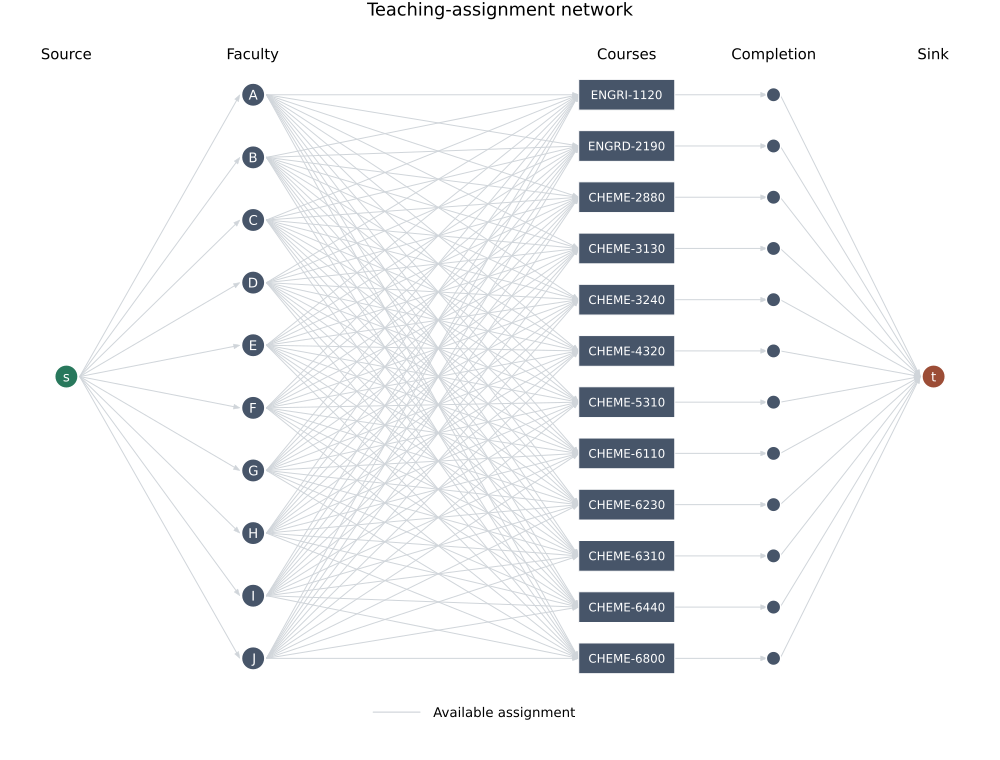

In [5]:
# Inspect the network before solving -
plot_teaching_flow(department, network; title = "Teaching-assignment network") # With no result argument, the plot shows the available assignments.

### Check: Totals before solving

Every assignment puts one faculty member in one course. It counts as one of the courses that person must teach, and it fills one instructor position in that course. Let $L_i$ be the number of courses faculty member $i$ must teach, so the faculty must teach $F=\sum_i L_i$ courses in total. Across all courses, the department must fill at least $\sum_k m_k$ instructor positions and can fill at most $\sum_k M_k$. Every feasible schedule must therefore satisfy:

$$
\sum_{k}m_k\;\leq\;F\;\leq\;\sum_{k}M_k.
$$

If $F$ is smaller than $\sum_k m_k$, some course is left short of the instructors it requires (the courses need more instructors than the faculty can supply). If $F$ is larger than $\sum_k M_k$, some faculty member cannot be given every course they must teach (the faculty must teach more courses than there are positions to fill). [The `staffing_totals(...)` function](docs/staffing_totals.md) returns $F$ as `total_load` and the two staffing totals as `total_min` and `total_max`. The `totals_ok` flag reports whether this necessary condition holds:

In [6]:
# Check whether the total load fits between the total staffing limits -
# This necessary check ignores which faculty can teach each course; it cannot prove feasibility.
totals = staffing_totals(department)

(total_load = 13, total_min = 10, total_max = 14, totals_ok = true)

### Things to think about

__What assumption does a default preference make?__ The network figure draws an edge from every faculty node to every course, and the count above reports 120 option edges, one for each faculty–course pair. Many of those pairs were blank in [the survey file](data/Preferences.csv), so the model keeps them available at the highest survey cost. Explain why this differs from prohibiting the assignment. If a faculty member cannot teach a particular course, would changing its cost express that restriction, or would its capacity need to change?

___

## Task 2: Formulate and solve the linear program

In this task, we assemble the linear program from the network, solve for a minimum-cost schedule, and check the returned assignments against the department's rules. We develop the minimum-cost-flow formulation from [the L5c lecture](../L5c/CHEME-5800-L5c-Lecture-LinearProgramming-Fall-2026.ipynb).

### From assignments to a linear program

We can represent the staffing allocation problem as a directed graph $G=(\mathcal{V},\mathcal{E})$, where $\mathcal{V}$ contains the nodes and $\mathcal{E}$ contains the directed edges. The __decision variable__ $f_j$ is the flow on edge $j$. Each edge represents a potential assignment, and the flow on that edge indicates whether that assignment is made. On a faculty-to-course edge, a flow of one indicates an assignment. The load, staffing, and completion edges carry those same assignments through the other layers of the network.

The department supplies three numbers for each edge: a lower bound $\ell_j$, an upper bound or capacity $c_j$, and a cost $w_j$ per assignment. These are fixed inputs. The solver chooses the entries of the flow vector $\mathbf{f}$, subject to the bounds and to conservation at every intermediate node. The required source-to-sink flow $F$ is determined by the sum of the faculty members' required teaching assignments; we are choosing how to distribute those assignments.

We express all node balances together using the __node–edge incidence matrix__ $\mathbf{A}$ and the prescribed net inflow vector $\mathbf{b}$. There is one row of $\mathbf{A}$ per node and one column per edge. We will construct this matrix shortly. The minimum-cost-flow linear program is given by:

$$
\begin{aligned}
\underset{\mathbf{f}}{\text{minimize}}\quad
    & \mathbf{w}^{\top}\mathbf{f}=\sum_{j\in\mathcal{E}}w_j f_j\\
\text{subject to}\quad
    & \mathbf{A}\mathbf{f}=\mathbf{b},\\
    & \ell_j\leq f_j\leq c_j,\qquad j\in\mathcal{E}.
\end{aligned}
$$

The objective adds the survey scores of the selected assignments; the other network edges have zero cost, so each assignment contributes its score once. The equality constraints enforce the required source and sink flows and conservation at intermediate nodes. The bounds enforce teaching loads and staffing limits. The lecture's zero lower bound is a special case: positive lower bounds let us enforce teaching loads and minimum course staffing.

This is a __linear program__ because the objective and constraints contain only sums of flow variables multiplied by fixed coefficients. A flow vector is __feasible__ when it satisfies every balance and bound. It is __optimal__ when no feasible flow vector has a smaller objective value. 

The cost and bound vectors have one entry per edge, the incidence matrix has one row per node and one column per edge, and the balance vector has one entry per node.

### Bounds and costs

We read $\ell_j$, $c_j$, and $w_j$ from the edges into the `lower`, `capacity`, and `w` arrays (using an [array comprehension](https://docs.julialang.org/en/v1/manual/arrays/#man-comprehensions)). Entry `j` in all three arrays must describe the same edge as column `j` of the incidence matrix; otherwise the solver would apply a cost or bound to the wrong assignment:

In [7]:
# Collect one entry per edge, preserving network.edges order -
# Entry j must refer to the same edge in all three vectors and in column j of A.
lower = [edge.lower for edge in network.edges]; # ℓ_j: minimum flow, in assignments
capacity = [edge.upper for edge in network.edges]; # c_j: maximum flow, in assignments
w = [edge.cost for edge in network.edges]; # w_j: survey-score points per assignment

### Required net flows

The vector $\mathbf{b}$ prescribes net inflow, meaning inflow minus outflow, at each node. The source $s$ supplies one unit per assignment, so its entry is negative; the sink $t$ collects those units, so its entry is positive. Let $L_i$ be the teaching load of the faculty member at node $i$. Summing over the faculty nodes gives a required total flow of $F=\sum_i L_i$ assignments. The entries of $\mathbf{b}$ are given by:

$$
b_i=\begin{cases}
-F, & i=s\quad\text{(source supplies the assignments)},\\
F, & i=t\quad\text{(sink collects the assignments)},\\
0, & \text{otherwise}\quad\text{(inflow equals outflow)}.
\end{cases}
$$

A faculty node has zero net inflow even when its teaching load is positive. Its incoming load edge supplies the assignments, and its outgoing course edges distribute them; conservation requires the two totals to agree. Course and completion nodes also pass on all the flow they receive. Only the source and sink exchange flow with the outside of this network.

In the next cell, `b` starts as a vector of zeros with one entry per node. We set only its source and sink entries, then display them to check their signs and magnitudes:

In [9]:
# Prescribe inflow minus outflow at every node -
b = let
    F = network.required_flow; # total teaching load, in assignments
    b = zeros(length(network.labels)); # intermediate nodes conserve flow: net inflow is zero
    b[network.source] = -F; # the source sends F more units than it receives
    b[network.sink] = F; # the sink receives F more units than it sends
    b # return the local vector as the value of the let block
end;

# Inspect the supply and demand entries; their sum must be zero -
(required_flow = network.required_flow, source_entry = b[network.source], sink_entry = b[network.sink])

(required_flow = 13.0, source_entry = -13.0, sink_entry = 13.0)

### The incidence matrix

How do we turn a directed edge into a balance equation? Each unit of flow on that edge leaves one node and enters another. The corresponding column of $\mathbf{A}$ must subtract that flow at its starting node and add it at its ending node. For node $i$ and edge $j$, we define the matrix entry by:

$$
A_{ij}=\begin{cases}
-1, & \text{edge }j\text{ leaves node }i,\\
1, & \text{edge }j\text{ enters node }i,\\
0, & \text{edge }j\text{ is not incident to node }i.
\end{cases}
$$

The matrix contains the network's connections and directions. Costs and bounds belong in their separate vectors. Multiplying row $i$ by the flow vector adds the incoming flows and subtracts the outgoing flows, so the row balance is given by:

$$
(\mathbf{A}\mathbf{f})_i
=\sum_{j:\,j\text{ enters }i}f_j
-\sum_{j:\,j\text{ leaves }i}f_j
=b_i.
$$

<style>
  .course-diagram { color-scheme: light dark; }
  :host-context(body[data-vscode-theme-kind="vscode-light"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast-light"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-light"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast-light"] .course-diagram { color-scheme: light; }
  :host-context(body[data-vscode-theme-kind="vscode-dark"]) .course-diagram,
  :host-context(body[data-vscode-theme-kind="vscode-high-contrast"]) .course-diagram,
  body[data-vscode-theme-kind="vscode-dark"] .course-diagram,
  body[data-vscode-theme-kind="vscode-high-contrast"] .course-diagram { color-scheme: dark; }
  @media print { .course-diagram { color-scheme: only light !important; } }
</style>
<p align="center">
<img class="course-diagram" src="../L5c/figs/Fig-MinCostFlow-ThreeNode.svg" width="650" style="display:block; margin:0 auto;" alt="Three-vertex flow network: edge 1 goes from s to v with capacity 2 and cost 1, edge 2 goes from v to t with capacity 2 and cost 1, and edge 3 goes directly from s to t with capacity 3 and cost 5.">
</p>

__Work through a small network.__ Consider the three-node example from L5c before assembling the teaching network. Edge 1 goes from $s$ to $v$, edge 2 goes from $v$ to $t$, and edge 3 goes directly from $s$ to $t$. For this small example only, suppose we must deliver $F=3$ units. Order the rows as $(s,v,t)$ and the columns as edges $(1,2,3)$. The balance equations are then given by:

$$
\underbrace{\begin{bmatrix}
-1&0&-1\\
1&-1&0\\
0&1&1
\end{bmatrix}}_{\mathbf{A}}
\underbrace{\begin{bmatrix}f_1\\f_2\\f_3\end{bmatrix}}_{\mathbf{f}}
=\underbrace{\begin{bmatrix}-3\\0\\3\end{bmatrix}}_{\mathbf{b}}.
$$

Read this matrix in both directions. Column 1 has a minus one at $s$ and a plus one at $v$, exactly the endpoints of edge 1. Row 1 requires $f_1+f_3=3$ units to leave the source. Row 2 requires $f_1=f_2$ at the intermediate node. Row 3 requires $f_2+f_3=3$ units to enter the sink. __Columns describe edges; rows describe node balances.__

__Return to the teaching network.__ We apply exactly the same incidence rule to every node and edge in the teaching network. We initialize `A` with one row per node and one column per edge. The loop visits each edge together with its index `j`, placing the two nonzero entries in that column. Node identifiers equal row indices in this network, so `edge.source` and `edge.target` select the required rows directly:

In [10]:
# Assemble the incidence matrix one edge column at a time -
A = let
    A = zeros(length(network.labels), length(network.edges)); # rows: nodes; columns: edges
    # Node identifiers equal row indices in this network; j is the edge's position.
    for (j, edge) in enumerate(network.edges)
        A[edge.source, j] = -1.0; # f_j is subtracted from the node where this edge begins
        A[edge.target, j] = 1.0; # f_j is added to the node where this edge ends
    end
    A # all other entries stay zero; the completed matrix is returned from the let block
end;

Before solving, we check the array dimensions and two consequences of conservation. Every column of $\mathbf{A}$ should sum to zero because an edge leaves one node and enters another. The entries of $\mathbf{b}$ should also sum to zero because the sink collects exactly what the source supplies.

We compare our matrix with the one returned by [the `flow_formulation(...)` function](docs/flow_formulation.md), which assembles the same model from the edge records. These are assembly checks; they do not establish feasibility or optimality.

In [11]:
# Check matrix dimensions, conservation signs, and agreement with the assembly helper -
@testset "Linear program arrays" begin
    @test size(A) == (length(network.labels), length(network.edges)) # node rows and edge columns
    @test all(sum(A; dims = 1) .== 0.0) # sum down each column: one -1 and one +1
    @test sum(b) == 0.0 # total supply equals total demand
    @test A == flow_formulation(network.edges, network.source, network.sink, network.required_flow).A
end;


Test Summary:         | Pass  

Total  Time
Linear program arrays |    4      4  0.4s


### Solve the linear program

[The `solve_flow_lp(...)` function](docs/solve_flow_lp.md) passes our arrays to JuMP and the GLPK solver. It returns `result`, which contains the termination status, the edge flows, and the objective value when a solution is optimal. The next cell displays the status and total cost. We need `OPTIMAL` before interpreting a minimum-cost schedule; an `INFEASIBLE` result has no schedule to read:

In [12]:
# Solve min wᵀf subject to Af = b and lower ≤ f ≤ capacity -
result = solve_flow_lp(network, A, b, w, lower, capacity); # JuMP model solved by GLPK

# Check status before interpreting flows; a nonoptimal result has no reported schedule or cost -
(status = result.status, total_cost = result.cost) # cost is measured in survey-score points

(status = OPTIMAL, total_cost = 4.0)

Let's unpack the solution. [The `teaching_schedule(...)` function](docs/teaching_schedule.md) produces one row per selected faculty–course pairing and retains its survey score and flow. We store this table in `schedule`, then use [the `assignments_by_faculty(...)` function](docs/assignments_by_faculty.md) to group the course names and scores by faculty member. Compare the number of listed courses with each person's load:

In [13]:
# Extract faculty-to-course flows as assignment rows -
schedule = teaching_schedule(department, network, result); # retain unrounded flows and survey scores

# Group assignments by faculty member to compare the schedule with the survey -
pretty_table(assignments_by_faculty(department, schedule);
    backend = :text,
    table_format = TextTableFormat(borders = text_table_borders__compact),
    column_labels = ["Faculty", "Load", "Courses", "Scores"], # course and score lists have matching order
    alignment = [:c, :r, :l, :l],
)

 --------- ------ ------------------------ --------
  Faculty   Load   Courses                  Scores 
 --------- ------ ------------------------ --------
     A         2   ENGRD-2190, CHEME-4320   0, 0
     B         1   CHEME-2880               0
     C         1   CHEME-3130               0
     D         2   CHEME-3240, CHEME-6230   0, 0
     E         1   CHEME-5310               0
     F         2   CHEME-6110, CHEME-6800   1, 0
     G         1   ENGRI-1120               0
     H         1   CHEME-4320               1
     I         1   CHEME-6310               0
     J         1   CHEME-4320               2
 --------- ------ ------------------------ --------


### Check the schedule against the model and the department

[The `validate_flow_solution(...)` function](docs/validate_flow.md) checks edge bounds and node balances and recomputes the cost from the returned flows. [The `schedule_checks(...)` function](docs/schedule_checks.md) confirms that faculty loads and course staffing meet the department's requirements.

The flows must also represent whole assignments. With integer bounds and required net flows, every corner of this network model's feasible region has integer flows. The simplex solver returns an optimal corner, giving whole assignments without integer decision variables. We check the returned flows for numerical error without rounding them.

The tests below use the absolute tolerance set in `check_tolerance` to verify feasibility, whole assignments, and cost. The solver's `OPTIMAL` status supplies the optimality claim:

In [14]:
# Set the numerical tolerance for checking a whole-assignment solution -
check_tolerance = 1e-8; # absolute tolerance, in assignments and score points

# Check the returned flows independently and count the resulting teaching assignments -
validation = validate_flow_solution(network.edges, result; atol = check_tolerance); # uses edge endpoints
checks = schedule_checks(department, schedule); # compare loads and staffing with the input tables
@testset "Schedule checks" begin
    @test result.status == MathOptInterface.OPTIMAL # the solver's optimality claim
    @test validation.valid # independently checked bounds, node balances, and recomputed cost
    @test checks.all_ok # exact faculty loads and course staffing intervals
    # Compare with the nearest integer without changing any returned flow.
    @test all(isapprox(value, round(value); atol = check_tolerance, rtol = 0.0)
        for value in result.vector)
end;

# Report the largest balance error and the objective computed directly from edge flows -
(maximum_balance_residual = validation.maximum_balance_residual,
 recomputed_cost = validation.recomputed_cost)

Test Summary:   | Pass  Total  Time
Schedule checks |    4      4  0.0s


(maximum_balance_residual = 0.0, recomputed_cost = 4.0)

[The `plot_teaching_flow(...)` function](docs/plot_teaching_flow.md) uses the same node positions as in Task 1. Red arrows now carry flow, and each faculty-to-course label gives its cost `w`, which here is its survey score. Count the red arrows entering the capstone, CHEME-4320, and compare the count with its required team size of three in the staffing table:

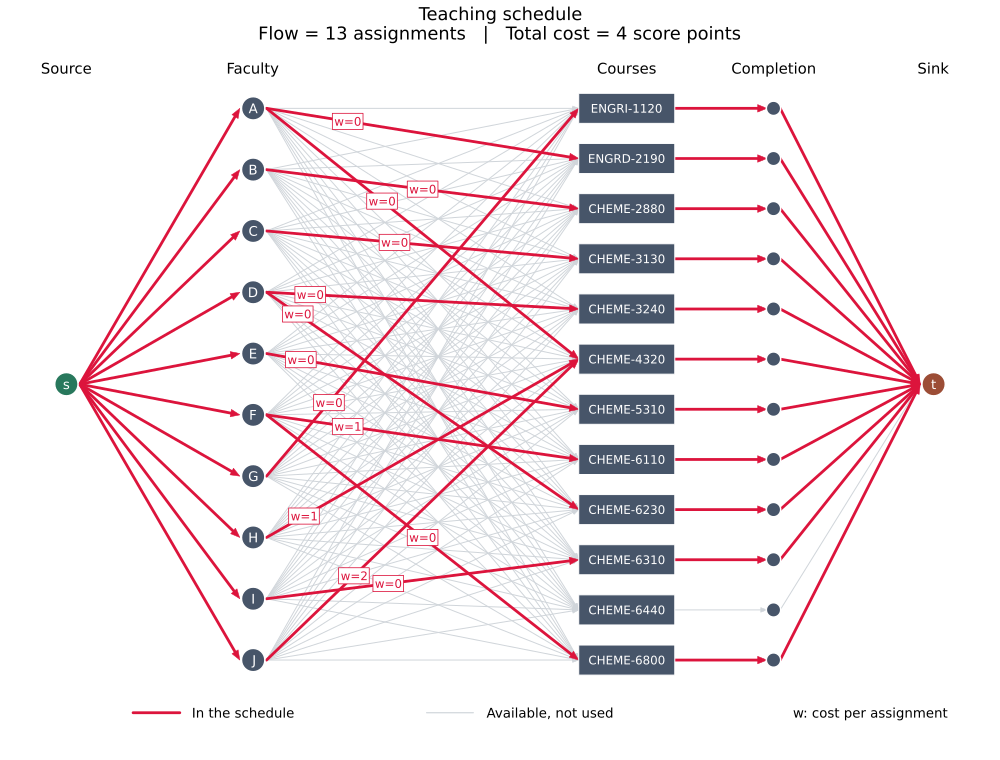

In [15]:
# Compare the selected assignments with the available network -
# Supplying result highlights the assignments selected by the solver.
plot_teaching_flow(department, network, result; title = "Teaching schedule")

An optional course's completion arrow stays gray when it receives no assignments. Such a course does not run in the displayed schedule. Compare the courses that run with the staffing table, and use the faculty-to-course labels to identify which assignments contribute to the objective. Those labels should add up to the total cost in the title.

### Things to think about

__Does the minimum-cost schedule give a fair teaching allocation?__ In the figure, J, the newest faculty member, carries the largest cost label: `w=2` on the capstone. Suppose the chair wants to move J to a course J scored a 1 in the survey table, CHEME-6110 or CHEME-6800. Follow the red arrows into those two courses back to the faculty member who teaches them now. Using the survey table, what could that person teach instead, and at what score? Explain why the chair must consider the effects on other faculty members, and whether minimizing the total score expresses the chair's preference.

___

## Task 3: Change the data and predict the schedule

In this task, we change the department's data and test how the optimal schedule responds. We will first change the cost of an existing assignment, then change a teaching load. Before we compute the new schedule for each case, we'll predict which assignments can still be made and which the objective will favor.

Each helper returns a changed copy, so `department::NamedTuple` retains our starting data. The functions give us two kinds of intervention:

* [The `with_preference(...)` function](docs/scenario_helpers.md) changes the cost of a faculty–course pairing; a blank restores the default. For any faculty–course pairing, [the `with_cost(...)` function](docs/scenario_helpers.md) sets any cost, including a bonus below zero.
* [The `with_load(...)` function](docs/scenario_helpers.md) changes a faculty teaching load, and [the `with_staffing(...)` function](docs/scenario_helpers.md) changes a course's staffing bounds.

### A change in cost

__Predict:__ Increase C's thermodynamics score using the value in the next cell. Does C keep CHEME 3130, and how does the total cost compare with the starting schedule?

The next cell stores the changed data in `scenario`, rebuilds its network, and solves it with [the `solve_min_cost_flow(...)` function](docs/solve_min_cost_flow.md). This helper assembles the arrays we constructed by hand in Task 2 before calling the same solver. The figure uses the changed survey scores and shows the new total cost. When trying another intervention, replace the `scenario` expression and update `change`, then rerun the whole cell so the network and solution reflect that intervention:

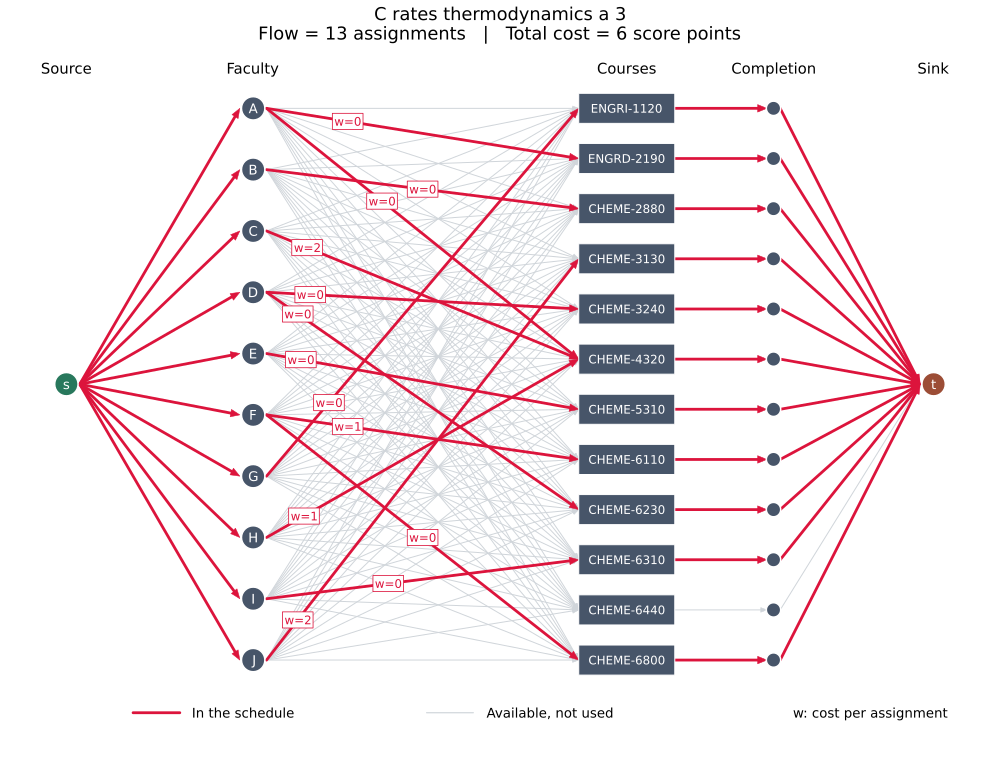

In [16]:
# Change one survey response in a copy of the starting department data -
change = "C rates thermodynamics a 3"; # describe the experiment in the figure title
scenario = with_preference(department, "C", "CHEME-3130", 3); # score points; the option remains available

# Predict the assignment changes, then rebuild and solve the modified model -
scenario_network = build_teaching_network(scenario); # transfer the new score to its edge cost
scenario_result = solve_min_cost_flow(scenario_network); # assemble fresh arrays and solve

# Display the schedule and cost, or the solver status if no optimum is available -
plot_teaching_flow(scenario, scenario_network, scenario_result; title = change)

Compare the new schedule with the starting schedule: does C still teach thermodynamics, and how does the total cost change? A higher cost discourages assigning C to this course, but any reassignment must still satisfy faculty teaching loads and course staffing requirements.

### A change in a bound

__Predict:__ B goes on sabbatical, so the next cell sets B's teaching load to zero. Can another faculty member cover CHEME 2880 under our default-preference rule? Predict how the schedule and total cost will change.

This cell starts again from `department`, so it does not retain C's changed score. B's load edge is fixed at zero, and the required total flow falls with the total teaching load. The course staffing bounds and available faculty–course pairings stay the same. We rebuild the network and solve:

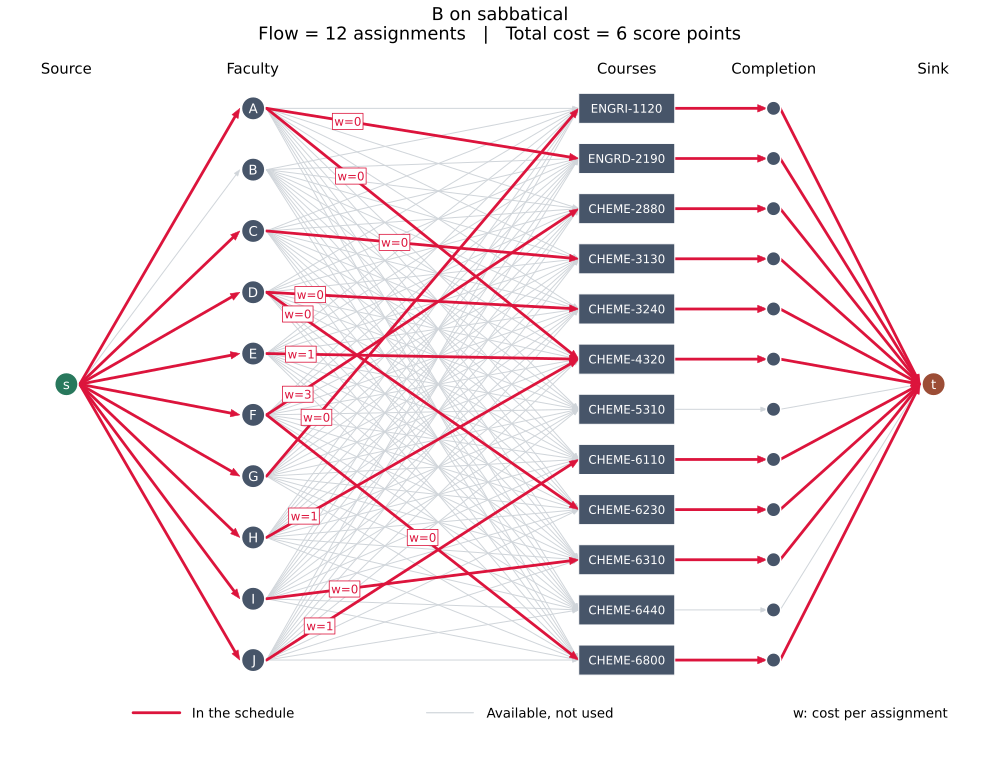

In [17]:
# Start a separate experiment from the starting department data -
change = "B on sabbatical"; # describe the experiment in the figure title
scenario = with_load(department, "B", 0); # zero assignments; C's original score is restored

# Predict feasibility, then rebuild with the new load and required total flow -
scenario_network = build_teaching_network(scenario); # B's load-edge bounds and the required total flow change
scenario_result = solve_min_cost_flow(scenario_network); # the solver checks all constraints together

# Display the changed schedule and cost, or the solver status if no schedule exists -
plot_teaching_flow(scenario, scenario_network, scenario_result; title = change)

The title reports a flow and a total cost, so the solver found a schedule. Follow the red arrow into CHEME-2880 back to the faculty member who covers it, and read its cost label. The default-preference rule allows the solver to use a pairing that had no supplied survey score. A feasible schedule therefore depends on that modeling assumption; its existence does not establish that the replacement instructor is prepared to teach the course.

Compare the optional courses that run with those in the starting schedule. Reducing a teaching load leaves fewer assignments to distribute after the required staffing is met. The bounds determine which courses may be left unstaffed, while the costs help determine which feasible schedule is selected.

### Things to think about

Try each change below in one of the what-if cells above. Replace the cell's `scenario` line with the call given, update `change`, and predict the result before you rerun the cell. The new figure's title and cost labels answer each question.

* __Question:__ Set C's thermodynamics score to 1 with [the `with_preference(...)` function](docs/scenario_helpers.md), `scenario = with_preference(department, "C", "CHEME-3130", 1)`, and then to 2. Each time, record the total cost and whether C still teaches CHEME-3130. The starting schedule cost 4, and a score of 3 gave a cost of 6. Why does the total cost rise with C's score and then stop rising? What does the equal cost at scores 2 and 3 tell us about the schedules?
* __Question:__ Offer J a bonus for thermodynamics with [the `with_cost(...)` function](docs/scenario_helpers.md), `scenario = with_cost(department, "J", "CHEME-3130", -1)`. J's survey score for the course is 2, so a cost of $-1$ is a bonus of 3 points. Who now teaches CHEME-3130 and the capstone, and what is the total cost? Use the cost labels on the edges that changed to explain why a cost of 1 would leave J on the capstone.
* __Question:__ Starting from B's sabbatical, give G a score of 2 for CHEME-2880 with `scenario = with_preference(with_load(department, "B", 0), "G", "CHEME-2880", 2)`. Does G move to the course? Then try a score of 0. If G moves, who covers G's current course, ENGRI-1120, and at what score? Explain why improving a score need not change the selected assignment.

___

## Summary

We modeled teaching assignments as a minimum-cost flow, solved the linear program, and changed its costs and bounds to see how the schedule responds.

> __Key Takeaways__
>
> * __Department rules as bounds and costs:__ We translated exact teaching loads and staffing limits into lower bounds and capacities, and we used survey scores as costs. Unspecified preferences received a default high score, allowing those pairings to be selected when they helped satisfy the department's rules.
>
> * __Building and solving the linear program:__ We assembled the incidence matrix, required net flows, costs, and bounds and solved for the lowest-cost schedule. Because this network's bounds and required net flows are whole numbers, the optimal corner returned by the simplex solver had whole-number flows, and we checked the resulting assignments against the department's rules.
>
> * __Changing costs and bounds:__ We predicted how the schedule would respond to each change and checked the prediction against the flow diagram. A change in cost reranked the same feasible schedules, while changing a teaching load altered the assignments available for required and optional courses.

In week 6, we apply the same linear programming tools to integrate metabolic networks: flux balance analysis uses a linear program with balance constraints and flux bounds to predict how a cell routes carbon and energy through its reactions.
___